# B. Feature Selection Using Funnelling Approach

## 2.a. Feature Selection Process Explanation

Feature selection is important as it largely impacts model accuracy. A model missing key features will be unable to classify inputs correctly; similarly, a model with too many features will have a lot of noise and redundancy which will also reduce classification abilities. Thus, it is important to not only select the right features, but also to avoid including too many.

The feature selection process is implemented as a multi-step funnel using filter, wrapper, and embedded methods. After starting with a large set of features to consider for the model, the process would reduce the set size by removing irrelevant and redundant features, while retaining the ones with the highest predictive value.

The first step, the Filter Method, removes features which have little to no effect on the output variable. This is done by observing the correlation between the feature and the output variable; features which contain little relationship or contain very little variance are removed. Additionally, among features which are similar (e.g. price: open, close, adjusted close), all but one can be removed as these features are near identical, eliminating redundancy. The first stage is computationally efficient and helps eliminate obvious noise before subsequent, expensive selection methods are applied.    

The second step is the Wrapper Method. After receiving a reduced feature set from the filter step, the wrapper method would evaluate subsets of features by repeatedly training a machine learning model on different feature subsets. It would iteratively remove the least useful features and assess the impact on model performance. Unlike filter methods, wrapper methods consider interactions between features and their contribution to predictive accuracy.

Finally, the Embedded Method will be applied. Embedded methods perform feature selection during the model training process itself. Feature importance scores will be generated by the model; these scores will be used to identify the features which contributed the most to prediction. Features with consistently low importance scores will be removed, producing the final feature subset.







## Before starting with 2.b., we first need to collect data and construct an initial feature set.

The objective of this coursework is to predict whether the next trading day will result in a positive or negative asset movement. To achieve this, historical stock market data for Google (GOOG) will be collected using Yahoo Finance. The raw dataset contains standard market variables such as Open, High, Low, Close, Adjusted Close, and Volume.

Following this, several engineered features will be created. These features will include measures of returns, momentum, volatility, moving averages, volume dynamics, and technical indicators such as RSI and MACD. Starting with a large feature set allows the subsequent feature selection process to identify the variables that contain the most predictive information.

Once the full feature set has been constructed, the funneling approach described in Section 2.a will be applied, with justifications found in 2.b. The resulting feature subset (to be outlined in 2.c) will then be used to train the final Gradient Boosting classification model.

In [1]:
import yfinance as yf
import pandas as pd
import numpy as np

# download GOOG data
df = yf.download(
    "GOOG",
    start="2019-05-01",
    end="2026-05-01",
    auto_adjust=True
)

df.head()

[*********************100%***********************]  1 of 1 completed


Price,Close,High,Low,Open,Volume
Ticker,GOOG,GOOG,GOOG,GOOG,GOOG
Date,,,,,
2019-05-01,57.928406,58.918776,57.883774,58.918776,52784000
2019-05-02,57.657143,58.231426,57.279839,57.912546,38896000
2019-05-03,58.787361,58.856791,57.974039,58.204644,39614000
2019-05-06,58.985245,59.057648,57.838160,57.838160,31278000
2019-05-07,58.226963,59.037308,57.579277,58.542866,31028000


In [2]:
# Create New Features

# create returns

df["ret_1"] = df["Close"].pct_change()
df["ret_3"] = df["Close"].pct_change(3)
df["ret_5"] = df["Close"].pct_change(5)
df["ret_10"] = df["Close"].pct_change(10)

# simple moving averages

df["SMA5"] = df["Close"].rolling(5).mean()
df["SMA10"] = df["Close"].rolling(10).mean()
df["SMA20"] = df["Close"].rolling(20).mean()
df["SMA50"] = df["Close"].rolling(50).mean()

# exponential moving averages

df["EMA5"] = df["Close"].ewm(span=5, adjust=False).mean()
df["EMA10"] = df["Close"].ewm(span=10, adjust=False).mean()
df["EMA20"] = df["Close"].ewm(span=20, adjust=False).mean()
df["EMA50"] = df["Close"].ewm(span=50, adjust=False).mean()

# rsi

delta = df["Close"].diff()

gain = delta.where(delta > 0, 0)
loss = -delta.where(delta < 0, 0)

avg_gain = gain.rolling(14).mean()
avg_loss = loss.rolling(14).mean()

rs = avg_gain / avg_loss

df["RSI14"] = 100 - (100 / (1 + rs))

# macd (macd, signal line, histogram)

ema12 = df["Close"].ewm(span=12, adjust=False).mean()
ema26 = df["Close"].ewm(span=26, adjust=False).mean()

df["MACD"] = ema12 - ema26
df["MACD_signal"] = df["MACD"].ewm(span=9, adjust=False).mean()
df["MACD_hist"] = df["MACD"] - df["MACD_signal"]

# kdj
low_n = df["Low"].rolling(9).min()
high_n = df["High"].rolling(9).max()

rsv = 100 * ((df["Close"] - low_n) / (high_n - low_n))
df["K"] = rsv.ewm(com=2).mean()
df["D"] = df["K"].ewm(com=2).mean()
df["J"] = 3 * df["K"] - 2 * df["D"]

# volatility features
df["vol_5"] = df["ret_1"].rolling(5).std()
df["vol_10"] = df["ret_1"].rolling(10).std()
df["vol_20"] = df["ret_1"].rolling(20).std()

# volume features

df["volume_change"] = df["Volume"].pct_change()
df["volume_ma20"] = df["Volume"].rolling(20).mean()

# bollinger band

rolling_mean = df["Close"].rolling(20).mean()
rolling_std = df["Close"].rolling(20).std()

upper_band = rolling_mean + 2 * rolling_std
lower_band = rolling_mean - 2 * rolling_std

df["bollinger_position"] = (
    (df["Close"] - lower_band) /
    (upper_band - lower_band)
)

print("Number of Feature Candidates:")
print(len(df.columns))

#df.head(25)

Number of Feature Candidates:
30


Features were constructed from four main categories: trend indicators (SMAs and EMAs), momentum indicators (RSI, MACD and KDJ), volatility measures, and volume-based indicators. These features were used because they capture different aspects of market behaviour and are commonly used in quantitative trading.

The initial feature set has 30 features to consider; in addition to the created features, raw "Close", "High", "Low", "Open", and "Volume" features are also considered for selection.

Sidenote: Rows containing NaNs generated by rolling-window and lagged feature calculations will be removed prior to model training.

In [3]:
df = df.dropna()

# makes sense as longest lookback period is EMA/SMA 50, so it makes sense rows without NaN would start in July
# df.head(10)

## 2.b. Justify the Selection of Features Retained at Each Step

### Filter Method

The filter method will be applied first to reduce the initial feature set. Correlation analysis will be used to identify highly correlated variables, allowing redundant features to be removed before proceeding to the wrapper and embedded stages.

Before applying the correlation filter, several features will be removed based on common knowledge. Open, High, and Low prices are highly correlated with the Close price and thus are redundant. Hence, Open, High, and Low will be removed.




In [4]:
df = df.drop(columns=[
    ("Open", "GOOG"),
    ("High", "GOOG"),
    ("Low", "GOOG")
])

In [5]:
# Now, we will identify highly correlated features

corr_matrix = df.corr(numeric_only=True).abs()

#print(corr_matrix)

# only look at the upper triangle to avoid duplicate comparisons
upper = corr_matrix.where(
    np.triu(np.ones(corr_matrix.shape), k=1).astype(bool)
)

# print all feature pairs with correlation above 0.95
for i in upper.columns:
    for j in upper.index:
        corr = upper.loc[j, i]

        if pd.notna(corr) and corr > 0.95:
            print(f"{j} vs. {i}: {corr:.3f}")


('Close', 'GOOG') vs. ('SMA5', ''): 0.999
('Close', 'GOOG') vs. ('SMA10', ''): 0.997
('SMA5', '') vs. ('SMA10', ''): 0.999
('Close', 'GOOG') vs. ('SMA20', ''): 0.994
('SMA5', '') vs. ('SMA20', ''): 0.997
('SMA10', '') vs. ('SMA20', ''): 0.998
('Close', 'GOOG') vs. ('SMA50', ''): 0.985
('SMA5', '') vs. ('SMA50', ''): 0.988
('SMA10', '') vs. ('SMA50', ''): 0.990
('SMA20', '') vs. ('SMA50', ''): 0.995
('Close', 'GOOG') vs. ('EMA5', ''): 0.999
('SMA5', '') vs. ('EMA5', ''): 1.000
('SMA10', '') vs. ('EMA5', ''): 0.999
('SMA20', '') vs. ('EMA5', ''): 0.997
('SMA50', '') vs. ('EMA5', ''): 0.988
('Close', 'GOOG') vs. ('EMA10', ''): 0.998
('SMA5', '') vs. ('EMA10', ''): 1.000
('SMA10', '') vs. ('EMA10', ''): 1.000
('SMA20', '') vs. ('EMA10', ''): 0.998
('SMA50', '') vs. ('EMA10', ''): 0.991
('EMA5', '') vs. ('EMA10', ''): 1.000
('Close', 'GOOG') vs. ('EMA20', ''): 0.996
('SMA5', '') vs. ('EMA20', ''): 0.998
('SMA10', '') vs. ('EMA20', ''): 0.999
('SMA20', '') vs. ('EMA20', ''): 1.000
('SMA50', 

#### Justification:

Correlation analysis showed that the SMA and EMA features formed a highly correlated group, with most pairwise correlations exceeding 0.95. As these indicators capture very similar trend information, retaining both types of features would introduce unnecessary redundancy. The SMA features are thus removed while the EMA features are retained for further evaluation in subsequent feature-selection stages. This is done as EMA indicators place greater emphasis on recent price movements, making them more responsive to asset value changes than SMA indicators.

Notably, the EMA features are also found to be highly correlated with each other and with the Close price. However, at this stage, it is not clear which feature among them is the most useful predictor, so the decision of choosing which feature to retain will be left to the wrapper and embedded methods later in the feature-selection process.

MACD and MACD_signal also showed a strong correlation of 0.958. The MACD_signal line will be removed in favour of retaining the MACD line. This is because another feature, the MACD histogram (difference between MACD line and its signal line), already captures the information provided by MACD_signal, making it redundant.

In [6]:
df = df.drop(columns=[
    ("SMA5", ""),
    ("SMA10", ""),
    ("SMA20", ""),
    ("SMA50", ""),
    ("MACD_signal", "")
])

print("Number of Feature Candidates:")
print(len(df.columns))


Number of Feature Candidates:
22


The number of feature candidates makes sense as we started with 30. After eliminating the 3 common sense price features (Open, High, Low) and the 5 features identified through correlation analysis, we are left with 30 - 3 - 5 = 22 features.

### Wrapper Method


In [7]:
# create target variable (output variable used to train/test) - if returns is positive = 1, else 0
df["target"] = (df["ret_1"].shift(-1) > 0).astype(int)

# drop final NaN created by shift
df = df.dropna()


Following the filter stage, Recursive Feature Elimination (RFE) was applied as the wrapper method. RFE repeatedly trains a machine learning model and removes the least important feature at each iteration until a specified number of features remains (10 in this case). This allows predictive performance to be considered directly when selecting variables.

In [8]:
from sklearn.feature_selection import RFE
from sklearn.ensemble import RandomForestClassifier

# separate features and targets
X = df.drop(columns=["target"])
y = df["target"]

# create model
rf = RandomForestClassifier(
    n_estimators=100,     # build 100 decision trees
    random_state=42       # seed
)

# rank features, keeping the 10 best
rfe = RFE(
    estimator=rf,
    n_features_to_select=10
)

# add data (may take a while to run)
rfe.fit(X, y)

RFE(estimator=RandomForestClassifier(random_state=42), n_features_to_select=10)

In [9]:
# return only features that should be kept according to RFE
selected_features = X.columns[rfe.support_]
print(selected_features)

MultiIndex([(     'Volume', 'GOOG'),
            (      'ret_1',     ''),
            (      'ret_3',     ''),
            (      'ret_5',     ''),
            (     'ret_10',     ''),
            (      'RSI14',     ''),
            (  'MACD_hist',     ''),
            (          'K',     ''),
            (          'D',     ''),
            ('volume_ma20',     '')],
           names=['Price', 'Ticker'])


#### Justification:

The wrapper stage was implemented using Recursive Feature Elimination (RFE) with a Random Forest classifier. RFE repeatedly trained the model and removed the least important feature until only 10 features remained (as specified in the code). The remaining selected features were volume, daily return, return (3 days), return (5 days), return (10 days), RSI14, MACD (histogram), K, D, and volume (20 day moving average).

These features can be justified from a technical perspective. Returns across different time horizons directly capture recent price movements and thus likely contain information relevant to future asset directions. RSI14 is also retained; it is a widely used momentum indicator that measures whether an asset may be overbought or oversold, which is a strong indicator for asset price direction on the next day. Similarly, MACD (histogram) was selected because it captures the difference between the MACD line and its signal line, providing information on momentum (more so than the raw MACD line itself).

The stochastic oscillator features K and D were also retained. These indicators compare the current price to its recent trading range and are commonly used to identify momentum shifts and potential trend reversals. Finally, Volume and volume (20 day moving average) were selected, suggesting that trading activity may provide useful information beyond just price movements. It is worth noting  that both current volume and average volume are included; this likely allows the model to identify periods of high or low market participation through comparison. Overall, the selected features are primarily related to price momentum, recent returns, and trading activity, all of which are commonly used in financial forecasting.

Interestingly, none of the EMA features were retained, suggesting that the information contained within the moving averages was largely captured by other return and momentum-based features (e.g. RSI, MACD, K and D). The EMAs simply were not adding enough extra predictive information.

The wrapper method also excluded volatility features and the Bollinger Band indicator. This suggests that these features provide little additional predictive information once returns, momentum indicators, and volume features were already included in the model. As a result, these features do not contribute significantly to model performance to warrant their retention.

### Embedded Method

The final stage of the feature-selection process uses an embedded method. As mentioned, embedded methods perform feature selection during model training itself. XGBoost will be used to generate feature importance scores for the features retained after the wrapper method. Features with higher importance scores contribute more to the model's predictions and are thus more valuable; the least important features will be removed to produce the final feature set used for model training.

In [10]:
from xgboost import XGBClassifier
import pandas as pd

# use features retained after wrapper method
X_embedded = X[selected_features]

# train XGBoost model
xgb = XGBClassifier(
    random_state=42,
    eval_metric="logloss" # standard loss function for binary classification
)

xgb.fit(X_embedded, y)

# extract feature importance
importance = pd.DataFrame({
    "Feature": X_embedded.columns,
    "Importance": xgb.feature_importances_
})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

importance

,Feature,Importance
3,"(ret_5, )",0.107301
5,"(RSI14, )",0.105604
2,"(ret_3, )",0.104648
8,"(D, )",0.102841
7,"(K, )",0.101062
4,"(ret_10, )",0.100956
1,"(ret_1, )",0.099619
9,"(volume_ma20, )",0.097192
6,"(MACD_hist, )",0.096933
0,"(Volume, GOOG)",0.083843


Justification:

From the final feature set produced, we can see that there is no single feature which dominates the model. This is good from a feature engineering perspective as it implies the model benefits from combining information from multiple features instead of relying on a single indicator alone.

The return-based features (ret_1, ret_3, ret_5, ret_10) account for 4 out of the 10 selected variables, indicating recent price information is highly important to predicting future asset directions. This makes sense as such data reflect short-term momentum, which is known to affect asset prices within financial markets.

The other momentum features (RSI14, K, D, and MACD_hist) were also retained and received relatively high importance scores. These features measure different aspects of price momentum and trend strength, reinforcing the idea that momentum contributes heavily to future price movements.

Finally, volume and volume (moving average 20) were also retained, indicating that trading activity provides information that the other retained features do not capture. The inclusion of both current volume and moving average volume suggests that relatively high/low market participation is heavily associated with asset direction.

Overall, the embedded method confirms the retained features from the wrapper stage; the relatively balanced importance scores suggest that each retained feature contributes useful information in the model.

In terms of which features to eliminate in this stage, I have decided to retain all 10 features. The embedded method did not identify any feature with significantly lower importance than the others, with all feature scores within a relatively small range. This implies all retained features contributed meaningful predictive information. As a result, no additional features will be removed; all 10 features will be retained as the final feature set.

An alternative approach would have been to compare models built using the top 10, 7 and 5 features and select the feature set that achieved the best ROC AUC, Accuracy, or F1 Score. However, given the score similarity and the lack of any clearly weak features, all 10 features were retained.

## 2.c. Final List of Selected Features

After starting with 30 features, the Filter Method funneled down the set to 22 features. The Wrapper Method then funneled it down to 10. The subsequent results from the Embedded Method confirmed this 10-feature set, suggesting these features are the most predictive for the model:

- 5-Day Return
- D from KDJ
- 3-Day Return
- 10-Day Return
- RSI-14
- Volume (20 Day Moving Average)
- K from KDJ
- MACD Histogram (Difference Between MACD and MACD Signal Line)
- Daily Return
- Volume


# C. Model Building, Tuning, and Evaluation

## 3.a. Build a Model to Predict Positive Market Moves

Before building the model, let's first verify whether we need to address class imbalance.

In [11]:
df["target"].value_counts(normalize = True)

,proportion
target,
1,0.544711
0,0.455289


The above result tells us the target variable is reasonably balanced, with approximately 54.5% positive observations and 45.5% negative observations. This means no additional class-balancing techniques (e.g. weighting, undersampling/oversampling) are required.

Having completed the feature-selection process, and verified that there is no class imbalance, the final set of 10 features will be used to construct a Gradient Boosting model. XGBoost will be the boosting algorithm used due to its strong predictive performance and efficient implementation of gradient boosting.

The target variable is defined as the direction of the following day's return (df["target"]). A positive return is labelled as 1 and a negative return will be labelled as 0.  

As this is a time-series project, the dataset will be split chronologically into training and testing sets. This avoids look-ahead bias by ensuring that future observations are not used when training the model.

In [12]:
from xgboost import XGBClassifier
from sklearn.metrics import roc_auc_score

# define final feeature set from feature selection process
final_features = [
    ('Volume', 'GOOG'),
    ('ret_1', ''),
    ('ret_3', ''),
    ('ret_5', ''),
    ('ret_10', ''),
    ('RSI14', ''),
    ('MACD_hist', ''),
    ('K', ''),
    ('D', ''),
    ('volume_ma20', '')
]

# create input matrix and target vector
X = df[final_features]
y = df["target"]

# use a 80/20 split
# first 80% of data are used for training
# final 20% are used for testing

split = int(len(df) * 0.8)

# input training/testing set
X_train = X.iloc[:split]
X_test = X.iloc[split:]

# target/output training/testing set
y_train = y.iloc[:split]
y_test = y.iloc[split:]

# create XGBoost classifier and fit data
xgb = XGBClassifier(
    random_state = 42,
    eval_metric = "logloss"
)
xgb.fit(X_train, y_train)

# Before tuning, check the ROC AUC to get benchmark before hyperparameter tuning

# generate predicted probabilities for the positive class
y_prob = xgb.predict_proba(X_test)[:, 1]

#calculate ROC AUC on unseen test set
roc_auc = roc_auc_score(y_test, y_prob)
print("ROC AUC: ", roc_auc)

ROC AUC:  0.5395982294858699


The initial XGBoost model achieved a ROC AUC score of approximately 0.5396 on the test set. Since a ROC AUC score of 0.5 corresponds to random guessing, we can infer that the model improvement over random classification through training is relatively limited. This result is not surprising, given that predicting short-term stock price movements is inherently challenging.

This result is a baseline benchmark because the model was trained using default XGBoost hyperparameters. Now that a reference point is established, we can measure the effectiveness of subsequent hyperparameter tuning. The next step is to optimise the model's parameters to improve predictive performance and to achieve a higher ROC AUC score.

## 3.b. Hyperparameter Tuning

The baseline XGBoost model trained using the algorithm's default settings provided an initial ROC AUC benchmark. This score and by extension, the model performance, can be improved by adjusting hyperparameters that control the learning behaviour of the boosting process. Hyperparameter tuning will be performed in this section to find a more effective model configuration.

Grid Search will be used to systematically evaluate different combinations of hyperparameter values. To avoid overfitting the model to a single validation period, a forward-chaining cross-validation approach will be used. For each fold, the model is trained on previously observed data and validated on data from a later time period (essentially a growing training window). This ensures chronological ordering, avoiding look-ahead bias, and allows for different hyperparameter combinations to be evaluated without using the test set.

A ROC AUC score will be calculated for each validation fold; these scores will be averaged to produce the mean cross-validation ROC AUC for that hyperparameter combination. The hyperparameter set with the highest average ROC AUC will be selected as it performs most consistently across different time periods rather than only performing well on one specific split.

The hyperparameters that I will tune are:
- n_estimators: The number of boosted trees used by the model. Too few trees may cause underfitting; too many trees can cause overfitting (model becomes unnecessarily complex).
- max_depth: Maximum depth of each decision tree. A higher depth allows the model to learn more complex patterns, but if it is too high, the model may overfit.
- learning_rate: How much each new tree contributes to the overall model. A high learning rate allows the model to learn quickly but can make it unstable/overfit; a low learning rate may require more trees to achieve a good performance.
- subsample: Proportion of training observations used when building each tree. Lower values introduce randomness and can reduce overfitting; if the value is too low, the model may not use enough data to learn patterns.
- colsample_bytree: Proportion of features used when building each tree. Lower values reduce overfitting by stopping the model from relying too much on the same features; if the value is too low, it may remove useful information.
- min_child_weight: Minimum number of data points required in a child node before a split is allowed. Larger values make the model more conservative and reduces overfitting; values that are too high prevents useful splits from being made.
- gamma: Minimum improvement in the objective function required for a split to occur. If the value is too low, model will be more likely to create additional splits, causing overfitting; if the value is too high, the model becomes too simple.
- reg_lambda: L2 regularisation parameter. A higher value punishes complex models and improves generalisation. On the other hand, too much regularisation causes underfitting.

In [13]:
from sklearn.model_selection import TimeSeriesSplit, GridSearchCV
from sklearn.metrics import accuracy_score

# TimeSeriesSplit -> keeps order of observations
# so future data is not used to predict the past
tscv = TimeSeriesSplit(n_splits=5)

xgb = XGBClassifier(
    random_state = 42,
    eval_metric = "logloss"
)

# hyperparameters to test; GridSearchCV will try every combination
# note the values in here are not the only ones tested
# a range of values for each hyperparameter were tested in combination to obtain
# the maximum ROC AUC. (including them all here would take too long)

# for simplicity, an example of grid definition for tuning is commented out below
# uncommented grid definition below contains the hyperparameter values
# that yielded the highest average ROC AUC (faster to run for examiner)

# param_grid = {
#     "n_estimators": [100,200,300],
#     "max_depth": [3,4,5, 6,8,10,12],
#     "learning_rate": [0.1, 0.2, 0.3],
#     "subsample": [0.4,0.5,0.6],
#     "colsample_bytree": [0.3,0.5,0.7,1.0],

#     "min_child_weight": [1, 3, 5, 7],
#     "gamma": [0, 0.1, 0.3, 0.5],
#     "reg_lambda": [0.5, 1, 2, 5]
# }

param_grid = {
    "n_estimators": [200],
    "max_depth": [6],
    "learning_rate": [0.3],
    "subsample": [0.5],
    "colsample_bytree": [1.0],

    "min_child_weight": [3],
    "gamma": [0],
    "reg_lambda": [0.5]
}



# set up GridSearchCV
grid_search = GridSearchCV(
    estimator = xgb,
    param_grid = param_grid,
    scoring = "roc_auc",
    cv = tscv,
    n_jobs = -1,
    verbose = 1 # print every fit
)

# fit GridSearchCV with training data
grid_search.fit(X_train, y_train)

# save best model
best_xgb = grid_search.best_estimator_

# print best hyperparameter combination
print("Best hyperparameters: ")
print(grid_search.best_params_)


# print the best average validation ROC AUC from cross-validation.
print("Best CV ROC AUC:")
print(grid_search.best_score_)



Fitting 5 folds for each of 1 candidates, totalling 5 fits
Best hyperparameters: 
{'colsample_bytree': 1.0, 'gamma': 0, 'learning_rate': 0.3, 'max_depth': 6, 'min_child_weight': 3, 'n_estimators': 200, 'reg_lambda': 0.5, 'subsample': 0.5}
Best CV ROC AUC:
0.5426768425112325


Following several rounds of Grid Search, the optimal hyperparameter are:
- n_estimators = 200
- max_depth = 6
- learning_rate = 0.3
- subsample = 0.5
- colsample_bytree = 1.0
- min_child_weight = 3
- gamma = 0
- reg_lambda = 0.5

This hyperparameter configuration consistently achieved the highest average ROC AUC across the validation folds (0.5427 in this case). The results show a slight improvement over the baseline model (0.5396 to 0.5427).

## 3.c. Model Prediction Quality Evaluation

The tuned XGBoost model is now evaluated on the unseen test set. Model performance will be assessed using ROC AUC, a ROC curve, a confusion matrix, and a classification report.

In [14]:
# use the tuned model to predict probabilities on the test set
y_prob_tuned = best_xgb.predict_proba(X_test)[:, 1]

# Convert probabilities into class predictions: 0 or 1.
y_pred_tuned = best_xgb.predict(X_test)

# Evaluate tuned model on the unseen test set.
roc_auc_tuned = roc_auc_score(y_test, y_prob_tuned)
accuracy_tuned = accuracy_score(y_test, y_pred_tuned)

print("Tuned Test ROC AUC:", roc_auc_tuned)
print("Tuned Test Accuracy:", accuracy_tuned)

Tuned Test ROC AUC: 0.5483486550902281
Tuned Test Accuracy: 0.5481049562682215


The tuned model achieved a test ROC AUC of 0.5483 and a test accuracy of 0.5481 on the unseen test dataset. Compared to the baseline model, which achieved a ROC AUC of 0.5396, the tuned model demonstrated a slight improvement in predictive performance. This suggests that hyperparameter tuning was successful in identifying a configuration that generalises slightly better to unseen data.

The optimal hyperparameter configuration achieved an average cross-validation ROC AUC of 0.5427, which is consistent with the final test ROC AUC of 0.5483. The similarity between these values indicates that the model did not overfit the validation folds during tuning and that the selected hyperparameters generalise relatively well to new observations.

Although the improvement over the baseline model is small, this outcome is expected. Predicting short-term stock movements is inherently challenging. Regardless, the results indicate that the selected technical indicators contain some predictive information which can be used to predict future price directions. The limited gains obtained through tuning also suggest that model performance is likely constrained more by feature choice than by the specific hyperparameter values.

### ROC Curve

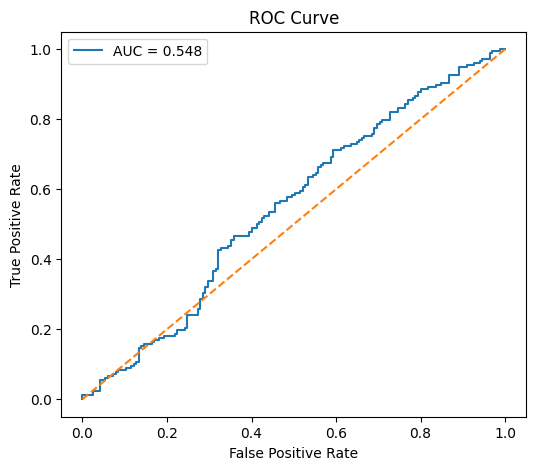

In [15]:
# ROC Curve

from sklearn.metrics import roc_curve
import matplotlib.pyplot as plt

fpr, tpr, thresholds = roc_curve(y_test, y_prob_tuned)

plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, label=f"AUC = {roc_auc_tuned:.3f}")
plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

The above figure shows the ROC curve for the tuned XGBoost model. The curve lies slightly above the diagonal random-classification line, which matches the final ROC AUC test score of 0.5483. This indicates the model possesses some ability to distinguish between positive and negative next-day movements and is slightly better than random guessing. However, the curve is still very close to the diagonal (with some parts of it going below it), suggesting that the model's predictive signal is still relatively weak. This is expected due to the difficulty of forecasting daily stock price movements, which can be influenced by many factors beyond the selected input features used for this project. In summary, the ROC curve confirms that the model contains some predictive power, though the strength of this signal is limited.

### Confusion Matrix

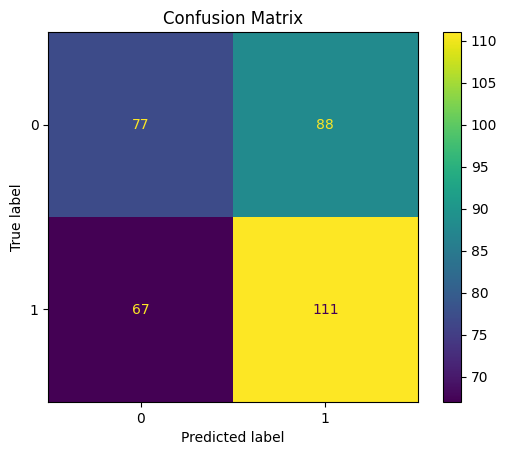

In [16]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_test, y_pred_tuned)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()
plt.title("Confusion Matrix")
plt.show()

The confusion matrix summarises the model's classification performance on the test set. Out of the 343 test observations, the model correctly classified 77 negative asset movements and 111 positive movements (true negatives and true positives respectively). However, it classified 88 negative movements as positive and 67 positive movements as negative (false positives and negatives respectively). Overall, the model correctly classified 188 out of 343 observations, which matches with the previously obtained accuracy value: 54.81%.

From the confusion matrix, we can infer that the model performs slightly better at identifying positive movements than negative ones. This is because there is a higher number of true positives (111) compared to true negatives (77), while there is a lower number of false negatives (67) compared to false positives (88).

The confusion matrix further reinforces that while the model demonstrates some predictive ability, the large number of misclassifications indicates that asset movement is hard to predict accurately. This is reflected by the ROC AUC score of 0.5483. Regardless, the model is able to classify direction more effectively than random guessing, suggesting that the selected input features for the model contain useful (but limited) predictive information.

It is also worth noting that the test set is fairly balanced (165 actual negatives compared to 178 actual positives; 48% vs. 52%), which means the accuracy is not affected by class imbalance.

### Classification Report

In [17]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred_tuned))

              precision    recall  f1-score   support

           0       0.53      0.47      0.50       165
           1       0.56      0.62      0.59       178

    accuracy                           0.55       343
   macro avg       0.55      0.55      0.54       343
weighted avg       0.55      0.55      0.55       343



The classification report provides a more detailed overview of model performance through the inclusion of precision, recall, and F1-score for each class.

Precision measures the proportion of predicted observations that were correctly classified (when the model predicts something, how often is it correct?), recall measures the proportion of actual observations that were correctly identified by the model (how many of the actual up-days did the model manage to identify?), and the F1 score combines both metrics through the harmonic mean.

For positive movements, the model achieved a precision of 0.56, recall of 0.62, and F1 score of 0.59. For negative movements, the model achieved a precision of 0.53, recall of 0.47, and F1 score of 0.5. The overall accuracy of the model was 0.55; similarly, the weighted-average precision, recall, and F1 score are all 0.55.

The results indicate that the model achieves a better balance between correctly identifying upward movements and avoiding incorrect positive predictions. This is reflected by the higher recall for positive movements (0.62 compared to 0.47). This means that the model successfully identified approximately 62% of all actual upward movements. By comparison, the recall for negative movements is only 0.47, meaning less than half of actual downward movements are correctly detected (which in theory is worse than random guessing). The model thus has a tendency to predict positive  movements more accurately.  

This is backed up by the precision scores. When the model predicts a positive movement, it is correct approximately 56% of the time, which is slightly higher than the 53% for negative movements.

This is also reflected in the F1 scores. The F1 score for positive movements is 0.59, compared to 0.5 for negative movements. Since the F1 score combines both precision and recall into a single metric, a higher value for positive movements indicates that the model performs better overall between correctly identifying upward movements and avoiding incorrect positive predictions.

Overall, the classification report is consistent with the confusion matrix and ROC AUC analysis, indicating that the model performs slightly better than random guessing overall, exhibiting very limited predictive power, with the model being slightly better at identifying upward movement than downward movement.

## Conclusion

In conclusion, this project developed and evaluated a machine learning model for predicting next-day positive movements in Google stock. After creating an initial feature set, a 3-stage feature selection process consisting of filter, wrapper, and embedded methods was then applied to reduce redundancy and identify the best predictors.

The filter stage removed highly correlated features, including the SMA indicators and the MACD signal line, while retaining EMA indicators for further evaluation. The wrapper stage, implemented using Recursive Feature Elimination (RFE) with a Random Forest classifier, identified 10 key features related to returns, momentum, and volume to retain. The embedded stage used XGBoost feature importance scores to then assess the relative contribution of these variables. Because all features exhibited similar importance, all 10 selected features were retained for model construction.

An XGBoost classifier was trained on stock price data between 01/05/2019 and 01/05/2026 using the final feature set and evaluated using an 80/20 chronological train-test split. Hyperparameter tuning was done using Grid Search combined with forward-chaining time-series cross-validation to ensure realistic forecasting conditions. The optimal hyperparameters achieved an average cross-validation ROC AUC of 0.5426. When evaluated on the test set, the tuned model achieved a ROC AUC of 0.5483, which is an improvement over the baseline model.

The ROC curve, confusion matrix, and classification report all indicated that the model has the ability to distinguish between positive and negative movements, although this predictive ability is relatively weak. The findings suggest that while the retained features contain useful predictive information, their ability to forecast short-term price direction is limited. Additionally, the small, limited gains obtained via hyperparameter tuning imply that the model performance is likely limited by the information content of the features used, rather than the values of the hyperparameters.  

Furthermore, the classification report and confusion matrix showed that the model was better at identifying positive movements than negative movements, achieving a recall of 0.62 and 0.47 respectively. If the model had to be used in practice, it may be better suited to a long-only trading strategy, where positions are taken only when the model predicts a positive return and no position is taken otherwise.  

